In [1]:
import os

In [2]:
!ls | grep json

artist_links.json


In [7]:
import pickle
import json
emb_file = 'available_emb.pcl'
art_file = 'available_art.pcl'
art_links_f = 'artist_links.json'
root_mp3 = '.songs_cache'
def _load_data():
    with open(emb_file,'rb') as f:
        emb = pickle.load(f)
    with open(art_file, 'rb') as f:
        art = pickle.load(f)
    with open(art_links_f,'r') as f:
        art_links = json.loads(f.read())
    return emb, art, art_links
emb, art, art_links = _load_data()


In [8]:
from utils import _preproc_track

In [ ]:
import numpy as np
from pydub import AudioSegment
import hashlib
from utils import ArtistData

def _make_ogg_from_segments(segments, output_file = 'output_sound.mp3'):
# --- Use the same audio parameters and data from the previous example ---
    sample_rate = 48000
    audio_data_float = np.hstack(segments)
    audio_data_int16 = np.int16(audio_data_float * 32767)


    # --- 1. Create a pydub AudioSegment from the NumPy array ---
    # We need to provide the raw data, sample width, frame rate, and channels.
    # sample_width=2 corresponds to 16-bit audio (2 bytes per sample).
    # channels=1 is for mono audio.
    sound = AudioSegment(
        data=audio_data_int16.tobytes(),
        sample_width=2,  # 2 bytes = 16 bits
        frame_rate=sample_rate,
        channels=1  # Mono
    )

    # --- 2. Export to a web-friendly format ---
    # Export as MP3
    sound.export(output_file, format="mp3", bitrate="192k")

def _make_example_for_artist(artist, artist_sample_folder = 'artist_samples'):
    ad = ArtistData(artist, art_links[artist], cache_folder=root_mp3)
    
    fname = 'artist_' + hashlib.md5(ad.artist.encode('utf-8')).hexdigest() + '.mp3'    
    
    for a in ad:
        preproc_res = _preproc_track(a[1])
        break
    _make_ogg_from_segments(preproc_res, os.path.join(artist_sample_folder, fname))
    print("ok - written " , fname)

In [18]:
# from tqdm import tqdm 
# for a in tqdm(art):
#     try:
#         _make_example_for_artist(a)
#     except:
#         print("skipped ... ")

In [20]:
# !mkdir artist_samples

In [51]:
norms = np.linalg.norm(emb, axis=1, keepdims=True)

In [55]:
norms = np.linalg.norm(emb, axis=1, keepdims=True)
emb_n = emb / norms

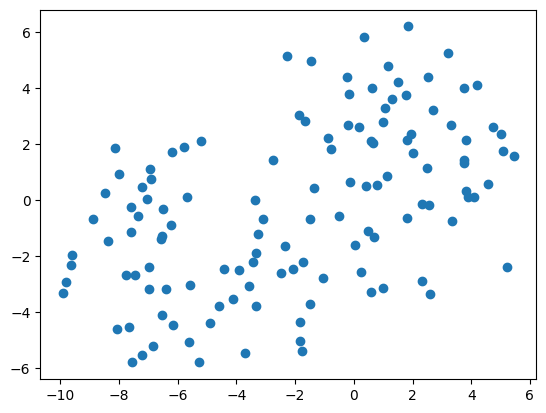

In [56]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as pplot
import numpy as np
c = TSNE().fit_transform(np.vstack(emb_n))
pplot.scatter(c[:,0], c[:,1])

In [69]:
from sklearn.cluster import SpectralClustering
import warnings

def cluster_embeddings_spectral(embeddings, num_clusters=10):
    """
    Performs Spectral Clustering on a set of embeddings.

    Args:
        embeddings (np.array): A 2D numpy array where each row is an embedding.
        num_clusters (int): The number of clusters to form.

    Returns:
        np.array: An array where each element is the cluster ID for the corresponding embedding.
    """
    # Initialize the Spectral Clustering model.
    # n_clusters: The number of clusters to find.
    # affinity: How to construct the affinity matrix. 'nearest_neighbors' is often a good choice.
    # random_state: Ensures reproducibility of the results.
    spectral = SpectralClustering(n_clusters=num_clusters,
                                  affinity='nearest_neighbors',
                                  random_state=42)

    # Fit the model to the embeddings data and return the labels.
    # Note: SpectralClustering doesn't compute cluster centers like KMeans.
    return spectral.fit_predict(embeddings)


In [83]:
clusters = cluster_embeddings_spectral(emb_n, num_clusters=10)

In [105]:
artist_data = []
for cc, x, y, a in zip(clusters, c[:,0], c[:,1], art):
    sample_path = "https://mylonasc.github.io/streetparade_artist_navigator" + os.path.join('/artist_samples', 'artist_' + hashlib.md5(a.encode('utf-8')).hexdigest() + '.mp3')
    curr_artist_link = '/'.join(art_links[a][0].split('/')[:-1] + ['tracks'])
        
    artist_data.append(
        {
            'cluster': int(cc), 
            'x' : float(x)+50, 
            'y'  : float(y)+50,
            'title' : a,
            'id' : a,
            'content' : a,
            'sound' : sample_path,
            'soundcloud' : curr_artist_link
            }
    )
    

In [106]:
clusters

array([3, 2, 2, 6, 6, 7, 3, 6, 2, 2, 1, 1, 0, 9, 0, 2, 5, 1, 6, 4, 4, 4,
       2, 0, 2, 7, 9, 3, 6, 7, 9, 3, 7, 4, 1, 8, 5, 0, 0, 5, 3, 1, 3, 2,
       2, 3, 4, 0, 4, 2, 0, 5, 7, 1, 1, 7, 5, 7, 1, 7, 7, 4, 3, 2, 9, 9,
       7, 0, 4, 0, 9, 9, 2, 4, 3, 4, 6, 6, 7, 4, 3, 8, 1, 4, 7, 3, 1, 3,
       3, 3, 1, 3, 6, 9, 1, 7, 7, 2, 7, 2, 8, 7, 1, 7, 1, 1, 4, 0, 6, 0,
       7, 1, 3, 6, 2, 2, 6, 2, 8, 1, 2, 3, 6, 8], dtype=int32)

In [ ]:
import json


def create_artist_visualization_page(artist_data):
    """
    Generates an HTML page with a D3.js scatterplot from artist data,
    including functionality to mark and list interesting points with persistence.

    Args:
        artist_data (list): A list of dictionaries, where each dictionary
                            represents an artist and contains keys like 'id', 'x', 'y',
                            'cluster', 'title', 'content', 'sound', and 'soundcloud'.

    Returns:
        str: A string containing the full HTML for the visualization page.
    """

    # Convert the Python list of dictionaries to a JSON string.
    dataset_json = json.dumps(artist_data, indent=4)

    html_template = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Interactive Artist Embedding Visualization</title>
    <script src="https://d3js.org/d3.v7.min.js"></script>
    <link rel="preconnect" href="https://fonts.googleapis.com">
    <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;700&display=swap" rel="stylesheet">
    <script src="https://cdn.tailwindcss.com"></script>
    <style>
        body {{
            font-family: 'Inter', sans-serif;
            background-color: #111827;
            color: #f3f4f6;
        }}
        .tooltip {{
            position: absolute;
            text-align: center;
            padding: 8px 12px;
            font-size: 14px;
            background: #1f2937;
            border: 1px solid #4b5563;
            border-radius: 8px;
            pointer-events: none;
            opacity: 0;
            transition: opacity 0.2s;
            box-shadow: 0 4px 6px rgba(0,0,0,0.3);
        }}
        .tooltip a {{
            color: #60a5fa;
            text-decoration: none;
        }}
        .tooltip a:hover {{
            text-decoration: underline;
        }}
        .axis path,
        .axis line {{
            stroke: #4b5563;
        }}
        .axis text {{
            fill: #9ca3af;
        }}
        .plot-bg {{
            fill: #1f2937;
        }}
        .dot {{
            transition: r 0.2s ease-in-out, stroke-width 0.2s ease-in-out, stroke 0.2s ease-in-out;
        }}
        .dot.marked {{
            stroke: #34d399; /* A bright green to indicate selection */
            stroke-width: 3px;
        }}
    </style>
</head>
<body class="flex flex-col items-center justify-center min-h-screen p-4 md:p-8">

    <div class="w-full max-w-6xl mx-auto">
        <h1 class="text-3xl md:text-4xl font-bold text-center mb-2 text-white">Street Parade '25 Navigator!</h1>
        <p class="text-center text-gray-400 mb-8">Hover over a point to see details. Each point is an artist/DJ. If two points are closer, the artist should sound similar. Click a point to load the audio and mark it so you check it out in the parade! Happy raving - enjoy! </p>

        <div class="grid grid-cols-1 lg:grid-cols-3 gap-8">
            <!-- Scatterplot Container -->
            <div id="visualization" class="w-full h-[500px] bg-gray-800 rounded-lg shadow-lg col-span-1 lg:col-span-2"></div>

            <!-- Sound Player and Info Container -->
            <div id="audio-container" class="w-full flex flex-col items-center justify-center bg-gray-800 rounded-lg p-6 shadow-lg h-[500px]">
                 <div id="info-placeholder" class="text-center text-gray-400">
                    <svg xmlns="http://www.w3.org/2000/svg" class="mx-auto h-12 w-12 text-gray-500" fill="none" viewBox="0 0 24 24" stroke="currentColor">
                        <path stroke-linecap="round" stroke-linejoin="round" stroke-width="2" d="M15.536 8.464a5 5 0 010 7.072m2.828-9.9a9 9 0 010 12.728M5.636 5.636a9 9 0 0112.728 0M8.464 15.536a5 5 0 010-7.072" />
                    </svg>
                    <p class="mt-4">Click a point on the scatterplot to play a sound snippet.</p>
                </div>
                <div id="player-wrapper" class="w-full"></div>
            </div>
        </div>

        <!-- Interesting Points List -->
        <div id="interesting-points-container" class="w-full mt-8 bg-gray-800 rounded-lg shadow-lg p-6">
            <h2 class="text-2xl font-bold mb-4 text-white">Interesting Points</h2>
            <ul id="interesting-points-list" class="space-y-2">
                <li id="interesting-list-placeholder" class="text-gray-400">Marked points will appear here.</li>
            </ul>
        </div>
    </div>

    <!-- Tooltip -->
    <div id="tooltip" class="tooltip"></div>

    <script>
        // --- 1. Data and State ---
        const dataset = {dataset_json};
        let interestingPoints = new Map(); // Use a Map to store marked points by ID for easy lookup

        // --- Persistence Functions ---
        function saveInterestingPoints() {{
            // localStorage can't store a Map directly, so convert it to an array of [key, value] pairs
            const pointsArray = Array.from(interestingPoints.entries());
            localStorage.setItem('artist-embedding-interesting-points', JSON.stringify(pointsArray));
        }}

        function loadInterestingPoints() {{
            const storedPoints = localStorage.getItem('artist-embedding-interesting-points');
            if (storedPoints) {{
                try {{
                    // If data exists, parse it and create a new Map from the array
                    const pointsArray = JSON.parse(storedPoints);
                    interestingPoints = new Map(pointsArray);
                }} catch (e) {{
                    console.error("Could not parse interesting points from localStorage", e);
                    interestingPoints = new Map();
                }}
            }}
        }}

        // Load saved points on page startup
        loadInterestingPoints();

        // --- 2. D3.js Visualization Setup ---
        const margin = {{ 'top': 40, 'right': 30, 'bottom': 50, 'left': 60 }};
        const container = document.getElementById('visualization');
        let width = container.clientWidth - margin.left - margin.right;
        let height = container.clientHeight - margin.top - margin.bottom;

        const svg = d3.select("#visualization")
            .append("svg")
            .attr("width", '100%')
            .attr("height", '100%')
            .attr('viewBox', `0 0 ${{container.clientWidth}} ${{container.clientHeight}}`)
            .append("g")
            .attr("transform", `translate(${{margin.left}}, ${{margin.top}})`);

        svg.append("rect").attr("width", width).attr("height", height).attr("class", "plot-bg");

        const xExtent = d3.extent(dataset, d => d.x);
        const yExtent = d3.extent(dataset, d => d.y);
        const xPadding = (xExtent[1] - xExtent[0]) * 0.1 || 10;
        const yPadding = (yExtent[1] - yExtent[0]) * 0.1 || 10;

        const xScale = d3.scaleLinear().domain([xExtent[0] - xPadding, xExtent[1] + xPadding]).range([0, width]);
        const yScale = d3.scaleLinear().domain([yExtent[0] - yPadding, yExtent[1] + yPadding]).range([height, 0]);
        const colorScale = d3.scaleOrdinal(d3.schemeCategory10).domain(d3.map(dataset, d => d.cluster));

        const xAxis = d3.axisBottom(xScale);
        const yAxis = d3.axisLeft(yScale);
        svg.append("g").attr("transform", `translate(0, ${{height}})`).attr("class", "axis").call(xAxis);
        svg.append("g").attr("class", "axis").call(yAxis);
        
        svg.append("text").attr("text-anchor", "end").attr("x", width / 2 + margin.left / 2).attr("y", height + margin.top).attr("fill", "#9ca3af").text("Embedding Dimension 1");
        svg.append("text").attr("text-anchor", "end").attr("transform", "rotate(-90)").attr("y", -margin.left + 20).attr("x", -height / 2 + margin.top).attr("fill", "#9ca3af").text("Embedding Dimension 2");

        const tooltip = d3.select("#tooltip");

        const dots = svg.selectAll(".dot")
            .data(dataset, d => d.id) // Use a key function for object constancy
            .enter()
            .append("circle")
            .attr("class", "dot")
            .attr("id", d => `dot-${{d.id}}`)
            .attr("cx", d => xScale(d.x))
            .attr("cy", d => yScale(d.y))
            .attr("r", 8)
            .style("fill", d => colorScale(d.cluster))
            .style("stroke", "#f3f4f6")
            .style("stroke-width", 0)
            .style("cursor", "pointer");

        // --- 3. Interaction and UI Update Functions ---

        function updateInterestingList() {{
            const list = d3.select("#interesting-points-list");
            list.html(''); // Clear the list

            if (interestingPoints.size === 0) {{
                list.append('li').attr('id', 'interesting-list-placeholder').attr('class', 'text-gray-400').text('Marked points will appear here.');
                return;
            }}

            interestingPoints.forEach((d, id) => {{
                const item = list.append('li')
                    .attr('class', 'flex justify-between items-center p-2 rounded-md hover:bg-gray-700');
                
                item.append('span')
                    .attr('class', 'cursor-pointer')
                    .text(d.title)
                    .on('click', () => {{
                        showPointDetails(d);
                        // Also highlight the dot on the plot
                        dots.style('opacity', 0.6);
                        d3.select(`#dot-${{d.id}}`).style('opacity', 1);
                    }});

                item.append('button')
                    .attr('class', 'text-red-400 hover:text-red-300 font-bold text-xl px-2')
                    .html('&times;') // The 'x' character for removal
                    .on('click', (event) => {{
                        event.stopPropagation(); // Prevent the li click event from firing
                        toggleMark(d);
                    }});
            }});
        }}
        
        function toggleMark(d) {{
            if (interestingPoints.has(d.id)) {{
                interestingPoints.delete(d.id);
            }} else {{
                interestingPoints.set(d.id, d);
            }}
            saveInterestingPoints(); // Save changes to localStorage
            
            // Update the visual state of all dots
            dots.classed('marked', dataPoint => interestingPoints.has(dataPoint.id));

            // Re-render the list and update the sidebar button
            updateInterestingList();
            showPointDetails(d);
        }}

        function showPointDetails(d) {{
            document.getElementById('info-placeholder').style.display = 'none';
            const playerWrapper = document.getElementById('player-wrapper');
            const isMarked = interestingPoints.has(d.id);

            playerWrapper.innerHTML = `
                <h3 class="text-xl font-bold mb-2 text-white">${{d.title}}</h3>
                <p class="text-gray-400 mb-4">${{d.content}}</p>
                <audio controls autoplay class="w-full rounded-lg">
                    <source src="${{d.sound}}" type="audio/mpeg">
                    Your browser does not support the audio element.
                </audio>
                <div class="flex space-x-4 mt-4">
                    <a href="${{d.soundcloud}}" target="_blank" class="flex-1 text-center px-4 py-2 bg-gray-600 text-white rounded-lg hover:bg-gray-500 transition-colors">
                        SoundCloud
                    </a>
                    <button id="mark-button" class="flex-1 px-4 py-2 rounded-lg transition-colors ${{isMarked ? 'bg-red-600 hover:bg-red-700' : 'bg-green-600 hover:bg-green-700'}}">
                        ${{isMarked ? 'Un-mark' : 'Mark as Interesting'}}
                    </button>
                </div>
            `;
            
            document.getElementById('mark-button').addEventListener('click', () => toggleMark(d));
        }}

        dots.on("mouseover", function(event, d) {{
            d3.select(this)
                .transition().duration(150)
                .attr("r", 12)
                .style("stroke-width", d3.select(this).classed('marked') ? 3 : 2);
            
            tooltip.transition().duration(200).style("opacity", .95);
            tooltip.html(`<b>${{d.title}}</b><br/>${{d.content}}`).style("left", (event.pageX + 15) + "px").style("top", (event.pageY - 28) + "px");
        }})
        .on("mouseout", function(d) {{
            d3.select(this)
                .transition().duration(150)
                .attr("r", 8)
                .style("stroke-width", d3.select(this).classed('marked') ? 3 : 0);

            tooltip.transition().duration(500).style("opacity", 0);
        }})
        .on("click", function(event, d) {{
            dots.style('opacity', 0.6);
            d3.select(this).style('opacity', 1);
            showPointDetails(d);
        }});

        // --- Initial Render on Load ---
        dots.classed('marked', d => interestingPoints.has(d.id));
        updateInterestingList();
        
        function resize() {{
            width = container.clientWidth - margin.left - margin.right;
            height = container.clientHeight - margin.top - margin.bottom;
            d3.select(container.querySelector('svg')).attr('viewBox', `0 0 ${{container.clientWidth}} ${{container.clientHeight}}`);
            xScale.range([0, width]);
            yScale.range([height, 0]);
            svg.select(".plot-bg").attr("width", width).attr("height", height);
            svg.select("g.axis:nth-of-type(1)").call(xAxis);
            svg.select("g.axis:nth-of-type(2)").call(yAxis);
            svg.select("g.axis:nth-of-type(3)").attr("transform", `translate(0, ${{height}})`).call(xAxis);
            svg.select("g.axis:nth-of-type(4)").call(yAxis);
            svg.select("text:nth-of-type(1)").attr("x", width / 2 + margin.left / 2).attr("y", height + margin.top);
            svg.select("text:nth-of-type(2)").attr("y", -margin.left + 20).attr("x", -height / 2 + margin.top);
            dots.attr("cx", d => xScale(d.x)).attr("cy", d => yScale(d.y));
        }}
        window.addEventListener('resize', resize);
    </script>
</body>
</html>
    """
    return html_template


def create_artist_visualization_page(artist_data):
    """
    Generates an HTML page with a D3.js scatterplot from artist data,
    including functionality to mark and list interesting points with persistence.

    Args:
        artist_data (list): A list of dictionaries, where each dictionary
                            represents an artist and contains keys like 'id', 'x', 'y',
                            'cluster', 'title', 'content', 'sound', and 'soundcloud'.

    Returns:
        str: A string containing the full HTML for the visualization page.
    """

    # Convert the Python list of dictionaries to a JSON string.
    dataset_json = json.dumps(artist_data, indent=4)

    html_template = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Interactive Artist Embedding Visualization</title>
    <script src="https://d3js.org/d3.v7.min.js"></script>
    <link rel="preconnect" href="https://fonts.googleapis.com">
    <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;700&display=swap" rel="stylesheet">
    <script src="https://cdn.tailwindcss.com"></script>
    <style>
        body {{
            font-family: 'Inter', sans-serif;
            background-color: #111827;
            color: #f3f4f6;
            position: relative; /* Needed for the pseudo-element */
        }}
        /* Tiled smiley background */
        body::before {{
            content: "";
            position: fixed;
            top: 0;
            left: 0;
            width: 100vw;
            height: 100vh;
            background-image: url('https://upload.wikimedia.org/wikipedia/commons/8/85/Smiley.svg');
            background-size: 80px 80px;
            background-repeat: repeat;
            opacity: 0.03;
            z-index: -1; /* Place it behind all content */
        }}
        .tooltip {{
            position: absolute;
            text-align: center;
            padding: 8px 12px;
            font-size: 14px;
            background: #1f2937;
            border: 1px solid #4b5563;
            border-radius: 8px;
            pointer-events: none;
            opacity: 0;
            transition: opacity 0.2s;
            box-shadow: 0 4px 6px rgba(0,0,0,0.3);
        }}
        .tooltip a {{
            color: #60a5fa;
            text-decoration: none;
        }}
        .tooltip a:hover {{
            text-decoration: underline;
        }}
        .axis path,
        .axis line {{
            stroke: #4b5563;
        }}
        .axis text {{
            fill: #9ca3af;
        }}
        .plot-bg {{
            fill: #1f2937;
        }}
        .dot {{
            transition: r 0.2s ease-in-out, stroke-width 0.2s ease-in-out, stroke 0.2s ease-in-out;
        }}
        .dot.marked {{
            stroke: #34d399; /* A bright green to indicate selection */
            stroke-width: 3px;
        }}
    </style>
</head>
<body class="flex flex-col items-center justify-center min-h-screen p-4 md:p-8">

    <div class="w-full max-w-6xl mx-auto">
        <h1 class="text-3xl md:text-4xl font-bold text-center mb-2 text-white">Artist Embedding Visualization</h1>
        <p class="text-center text-gray-400 mb-8">Hover over a point to see details. Click a point to load the audio and mark it.</p>

        <div class="grid grid-cols-1 lg:grid-cols-3 gap-8">
            <!-- Scatterplot Container -->
            <div id="visualization" class="w-full h-[500px] bg-gray-800 rounded-lg shadow-lg col-span-1 lg:col-span-2"></div>

            <!-- Sound Player and Info Container -->
            <div id="audio-container" class="w-full flex flex-col items-center justify-center bg-gray-800 rounded-lg p-6 shadow-lg h-[500px]">
                 <div id="info-placeholder" class="text-center text-gray-400">
                    <svg xmlns="http://www.w3.org/2000/svg" class="mx-auto h-12 w-12 text-gray-500" fill="none" viewBox="0 0 24 24" stroke="currentColor">
                        <path stroke-linecap="round" stroke-linejoin="round" stroke-width="2" d="M15.536 8.464a5 5 0 010 7.072m2.828-9.9a9 9 0 010 12.728M5.636 5.636a9 9 0 0112.728 0M8.464 15.536a5 5 0 010-7.072" />
                    </svg>
                    <p class="mt-4">Click a point on the scatterplot to play a sound snippet.</p>
                </div>
                <div id="player-wrapper" class="w-full"></div>
            </div>
        </div>

        <!-- Interesting Points List -->
        <div id="interesting-points-container" class="w-full mt-8 bg-gray-800 rounded-lg shadow-lg p-6">
            <h2 class="text-2xl font-bold mb-4 text-white">Interesting Points</h2>
            <ul id="interesting-points-list" class="space-y-2">
                <li id="interesting-list-placeholder" class="text-gray-400">Marked points will appear here.</li>
            </ul>
        </div>
    </div>

    <!-- Tooltip -->
    <div id="tooltip" class="tooltip"></div>

    <script>
        // --- 1. Data and State ---
        const dataset = {dataset_json};
        let interestingPoints = new Map(); // Use a Map to store marked points by ID for easy lookup

        // --- Persistence Functions ---
        function saveInterestingPoints() {{
            // localStorage can't store a Map directly, so convert it to an array of [key, value] pairs
            const pointsArray = Array.from(interestingPoints.entries());
            localStorage.setItem('artist-embedding-interesting-points', JSON.stringify(pointsArray));
        }}

        function loadInterestingPoints() {{
            const storedPoints = localStorage.getItem('artist-embedding-interesting-points');
            if (storedPoints) {{
                try {{
                    // If data exists, parse it and create a new Map from the array
                    const pointsArray = JSON.parse(storedPoints);
                    interestingPoints = new Map(pointsArray);
                }} catch (e) {{
                    console.error("Could not parse interesting points from localStorage", e);
                    interestingPoints = new Map();
                }}
            }}
        }}

        // Load saved points on page startup
        loadInterestingPoints();

        // --- 2. D3.js Visualization Setup ---
        const margin = {{ 'top': 40, 'right': 30, 'bottom': 50, 'left': 60 }};
        const container = document.getElementById('visualization');
        let width = container.clientWidth - margin.left - margin.right;
        let height = container.clientHeight - margin.top - margin.bottom;

        const svg = d3.select("#visualization")
            .append("svg")
            .attr("width", '100%')
            .attr("height", '100%')
            .attr('viewBox', `0 0 ${{container.clientWidth}} ${{container.clientHeight}}`)
            .append("g")
            .attr("transform", `translate(${{margin.left}}, ${{margin.top}})`);

        svg.append("rect").attr("width", width).attr("height", height).attr("class", "plot-bg");

        const xExtent = d3.extent(dataset, d => d.x);
        const yExtent = d3.extent(dataset, d => d.y);
        const xPadding = (xExtent[1] - xExtent[0]) * 0.1 || 10;
        const yPadding = (yExtent[1] - yExtent[0]) * 0.1 || 10;

        const xScale = d3.scaleLinear().domain([xExtent[0] - xPadding, xExtent[1] + xPadding]).range([0, width]);
        const yScale = d3.scaleLinear().domain([yExtent[0] - yPadding, yExtent[1] + yPadding]).range([height, 0]);
        const colorScale = d3.scaleOrdinal(d3.schemeCategory10).domain(d3.map(dataset, d => d.cluster));

        const xAxis = d3.axisBottom(xScale);
        const yAxis = d3.axisLeft(yScale);
        svg.append("g").attr("transform", `translate(0, ${{height}})`).attr("class", "axis").call(xAxis);
        svg.append("g").attr("class", "axis").call(yAxis);
        
        svg.append("text").attr("text-anchor", "end").attr("x", width / 2 + margin.left / 2).attr("y", height + margin.top).attr("fill", "#9ca3af").text("Embedding Dimension 1");
        svg.append("text").attr("text-anchor", "end").attr("transform", "rotate(-90)").attr("y", -margin.left + 20).attr("x", -height / 2 + margin.top).attr("fill", "#9ca3af").text("Embedding Dimension 2");

        const tooltip = d3.select("#tooltip");

        const dots = svg.selectAll(".dot")
            .data(dataset, d => d.id) // Use a key function for object constancy
            .enter()
            .append("circle")
            .attr("class", "dot")
            .attr("id", d => `dot-${{d.id}}`)
            .attr("cx", d => xScale(d.x))
            .attr("cy", d => yScale(d.y))
            .attr("r", 8)
            .style("fill", d => colorScale(d.cluster))
            .style("stroke", "#f3f4f6")
            .style("stroke-width", 0)
            .style("cursor", "pointer");

        // --- 3. Interaction and UI Update Functions ---

        function updateInterestingList() {{
            const list = d3.select("#interesting-points-list");
            list.html(''); // Clear the list

            if (interestingPoints.size === 0) {{
                list.append('li').attr('id', 'interesting-list-placeholder').attr('class', 'text-gray-400').text('Marked points will appear here.');
                return;
            }}

            interestingPoints.forEach((d, id) => {{
                const item = list.append('li')
                    .attr('class', 'flex justify-between items-center p-2 rounded-md hover:bg-gray-700');
                
                item.append('span')
                    .attr('class', 'cursor-pointer')
                    .text(d.title)
                    .on('click', () => {{
                        showPointDetails(d);
                        // Also highlight the dot on the plot
                        dots.style('opacity', 0.6);
                        d3.select(`#dot-${{d.id}}`).style('opacity', 1);
                    }});

                item.append('button')
                    .attr('class', 'text-red-400 hover:text-red-300 font-bold text-xl px-2')
                    .html('&times;') // The 'x' character for removal
                    .on('click', (event) => {{
                        event.stopPropagation(); // Prevent the li click event from firing
                        toggleMark(d);
                    }});
            }});
        }}
        
        function toggleMark(d) {{
            if (interestingPoints.has(d.id)) {{
                interestingPoints.delete(d.id);
            }} else {{
                interestingPoints.set(d.id, d);
            }}
            saveInterestingPoints(); // Save changes to localStorage
            
            // Update the visual state of all dots
            dots.classed('marked', dataPoint => interestingPoints.has(dataPoint.id));

            // Re-render the list and update the sidebar button
            updateInterestingList();
            showPointDetails(d);
        }}

        function showPointDetails(d) {{
            document.getElementById('info-placeholder').style.display = 'none';
            const playerWrapper = document.getElementById('player-wrapper');
            const isMarked = interestingPoints.has(d.id);

            playerWrapper.innerHTML = `
                <h3 class="text-xl font-bold mb-2 text-white">${{d.title}}</h3>
                <p class="text-gray-400 mb-4">${{d.content}}</p>
                <audio controls autoplay class="w-full rounded-lg">
                    <source src="${{d.sound}}" type="audio/mpeg">
                    Your browser does not support the audio element.
                </audio>
                <div class="flex space-x-4 mt-4">
                    <a href="${{d.soundcloud}}" target="_blank" class="flex-1 text-center px-4 py-2 bg-gray-600 text-white rounded-lg hover:bg-gray-500 transition-colors">
                        SoundCloud
                    </a>
                    <button id="mark-button" class="flex-1 px-4 py-2 rounded-lg transition-colors ${{isMarked ? 'bg-red-600 hover:bg-red-700' : 'bg-green-600 hover:bg-green-700'}}">
                        ${{isMarked ? 'Un-mark' : 'Mark as Interesting'}}
                    </button>
                </div>
            `;
            
            document.getElementById('mark-button').addEventListener('click', () => toggleMark(d));
        }}

        dots.on("mouseover", function(event, d) {{
            d3.select(this)
                .transition().duration(150)
                .attr("r", 12)
                .style("stroke-width", d3.select(this).classed('marked') ? 3 : 2);
            
            tooltip.transition().duration(200).style("opacity", .95);
            tooltip.html(`<b>${{d.title}}</b><br/>${{d.content}}`).style("left", (event.pageX + 15) + "px").style("top", (event.pageY - 28) + "px");
        }})
        .on("mouseout", function(d) {{
            d3.select(this)
                .transition().duration(150)
                .attr("r", 8)
                .style("stroke-width", d3.select(this).classed('marked') ? 3 : 0);

            tooltip.transition().duration(500).style("opacity", 0);
        }})
        .on("click", function(event, d) {{
            dots.style('opacity', 0.6);
            d3.select(this).style('opacity', 1);
            showPointDetails(d);
        }});

        // --- Initial Render on Load ---
        dots.classed('marked', d => interestingPoints.has(d.id));
        updateInterestingList();
        
        function resize() {{
            width = container.clientWidth - margin.left - margin.right;
            height = container.clientHeight - margin.top - margin.bottom;
            d3.select(container.querySelector('svg')).attr('viewBox', `0 0 ${{container.clientWidth}} ${{container.clientHeight}}`);
            xScale.range([0, width]);
            yScale.range([height, 0]);
            svg.select(".plot-bg").attr("width", width).attr("height", height);
            svg.select("g.axis:nth-of-type(1)").call(xAxis);
            svg.select("g.axis:nth-of-type(2)").call(yAxis);
            svg.select("g.axis:nth-of-type(3)").attr("transform", `translate(0, ${{height}})`).call(xAxis);
            svg.select("g.axis:nth-of-type(4)").call(yAxis);
            svg.select("text:nth-of-type(1)").attr("x", width / 2 + margin.left / 2).attr("y", height + margin.top);
            svg.select("text:nth-of-type(2)").attr("y", -margin.left + 20).attr("x", -height / 2 + margin.top);
            dots.attr("cx", d => xScale(d.x)).attr("cy", d => yScale(d.y));
        }}
        window.addEventListener('resize', resize);
    </script>
</body>
</html>
    """
    return html_template

In [113]:
artist_data

[{'cluster': 3,
  'x': 45.58245515823364,
  'y': 47.53331160545349,
  'title': '7ubo',
  'id': '7ubo',
  'content': '7ubo',
  'sound': 'https://mylonasc.github.io/streetparade_artist_navigator/artist_samples/artist_b5892c035b3e5673216b1e8ad9f5f4f9.mp3',
  'soundcloud': 'https://soundcloud.com/7ubo/tracks'},
 {'cluster': 2,
  'x': 51.95336139202118,
  'y': 52.367661476135254,
  'title': 'AANN x ANCHI • Style am Rhein (SH)',
  'id': 'AANN x ANCHI • Style am Rhein (SH)',
  'content': 'AANN x ANCHI • Style am Rhein (SH)',
  'sound': 'https://mylonasc.github.io/streetparade_artist_navigator/artist_samples/artist_fe216e76c283dfa4c5ac15c8ef59e94b.mp3',
  'soundcloud': 'https://soundcloud.com/aannmusic/tracks'},
 {'cluster': 2,
  'x': 51.52075517177582,
  'y': 54.23056650161743,
  'title': 'Aaron Khaleian',
  'id': 'Aaron Khaleian',
  'content': 'Aaron Khaleian',
  'sound': 'https://mylonasc.github.io/streetparade_artist_navigator/artist_samples/artist_015fa65d860fa4b8554e39f9acd7f8a3.mp3',
  

In [114]:
len(artist_data)

124

In [115]:
html_page = create_artist_visualization_page(artist_data)

In [116]:
with open('/tmp/page.html','w') as f:
    f.write(html_page)
    
!scp /tmp/page.html ideapad:/tmp/page.html
# !cp /tmp/page.html streetparade_artist_navigator/index.html

page.html                                     100%   62KB   6.3MB/s   00:00    
